# NBA Draft Combine Exploratory Data Analysis

# Research Questions

1. How many players participated in the combine by position?
2. What is the average weight of centers, and how does it compare to the average combine player?
3. What is the relationship between height and weight among combine players?
4. Is there a correlation between wingspan and maximum vertical leap?
5. Which guards qualify as elite athletes based on vertical leap, standing reach, and wingspan percentile rankings?
6. Who were the tallest and heaviest players in each combine season?

# Key Skills Used

- Python
- Pandas
- Matplotlib
- Exploratory Data Analysis (EDA)
- Data Cleaning
- Data Visualization

Importing necessary libraries.

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

Reading in the dataset (NBA draft combine dataset from Kaggle).

In [ ]:
df = pd.read_csv('draft_combine_stats.csv')

Checking what columns comprise the dataset.

In [14]:
df.columns

Index(['season', 'player_id', 'first_name', 'last_name', 'player_name',
       'position', 'height_wo_shoes', 'height_wo_shoes_ft_in',
       'height_w_shoes', 'height_w_shoes_ft_in', 'weight', 'wingspan',
       'wingspan_ft_in', 'standing_reach', 'standing_reach_ft_in',
       'body_fat_pct', 'hand_length', 'hand_width', 'standing_vertical_leap',
       'max_vertical_leap', 'lane_agility_time', 'modified_lane_agility_time',
       'three_quarter_sprint', 'bench_press', 'spot_fifteen_corner_left',
       'spot_fifteen_break_left', 'spot_fifteen_top_key',
       'spot_fifteen_break_right', 'spot_fifteen_corner_right',
       'spot_college_corner_left', 'spot_college_break_left',
       'spot_college_top_key', 'spot_college_break_right',
       'spot_college_corner_right', 'spot_nba_corner_left',
       'spot_nba_break_left', 'spot_nba_top_key', 'spot_nba_break_right',
       'spot_nba_corner_right', 'off_drib_fifteen_break_left',
       'off_drib_fifteen_top_key', 'off_drib_fifteen_bre

Filtering out useless columns.

In [20]:
df = df[['season', 'player_id', 'player_name', 'position', 'height_wo_shoes', 'wingspan', 'weight', 'standing_reach', 'max_vertical_leap']]

Some summary statistics.

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1202 entries, 0 to 1201
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   season             1202 non-null   int64  
 1   player_id          1202 non-null   int64  
 2   player_name        1202 non-null   object 
 3   position           1197 non-null   object 
 4   height_wo_shoes    1153 non-null   float64
 5   wingspan           1153 non-null   float64
 6   weight             1152 non-null   float64
 7   standing_reach     1152 non-null   float64
 8   max_vertical_leap  1017 non-null   float64
dtypes: float64(5), int64(2), object(2)
memory usage: 84.6+ KB


In [22]:
df.describe()

,season,player_id,height_wo_shoes,wingspan,weight,standing_reach,max_vertical_leap
count,1202.000000,1.202000e+03,1153.000000,1153.000000,1152.000000,1152.000000,1017.000000
mean,2012.536606,2.350133e+06,77.570902,82.478187,214.902604,103.593663,34.637168
std,6.561620,5.660210e+07,3.334605,3.986623,25.718878,4.880218,3.648106
min,2001.000000,-1.000000e+00,67.750000,70.000000,154.400000,89.500000,25.000000
25%,2007.000000,1.011455e+05,75.250000,80.000000,195.950000,100.000000,32.000000
50%,2012.000000,2.031470e+05,77.750000,82.750000,212.900000,104.000000,34.500000
75%,2018.000000,1.629014e+06,80.000000,85.250000,233.000000,107.000000,37.000000
max,2023.000000,1.962937e+09,89.250000,98.250000,314.000000,122.500000,45.500000


Cleaning NA rows.

In [68]:
df = df.dropna()

# Answer (1)

In [33]:
df['position'].value_counts()

position
PF       216
PG       201
SG       193
SF       148
C        106
SG-SF     64
PF-C      49
SF-PF     44
C-PF      44
PG-SG     40
PF-SF     34
SF-SG     33
SG-PG     25
Name: count, dtype: int64

Text(0, 0.5, 'Count')

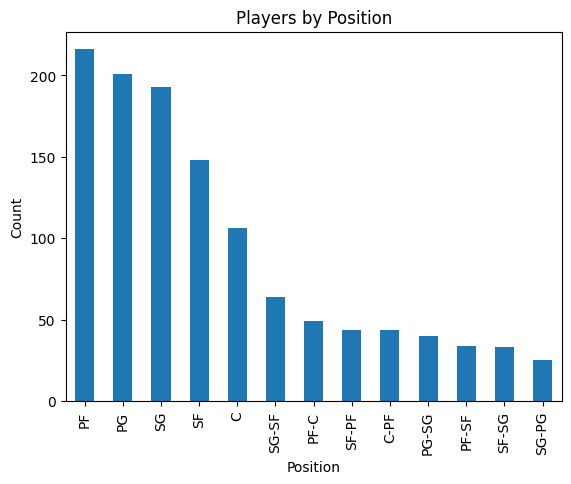

In [40]:
df['position'].value_counts().plot(kind='bar')

plt.title('Players by Position')
plt.xlabel('Position')
plt.ylabel('Count')

The combine dataset is relatively balanced across major positions, although forwards and guards appear more frequently than centers. Hybrid position labels indicate that many prospects possess versatile skill sets capable of fitting multiple on-court roles.

# Answer (2)

In [49]:
round(df[df['position'] == 'C']['weight'].mean(), 2)

np.float64(250.35)

In [51]:
round(df['weight'].mean(), 2)

np.float64(214.9)

Centers had an average weight of approximately 250.35 pounds, which is significantly higher than the overall combine average weight of 214.90 pounds. This reflects the physical demands of the center position, where players are generally taller, stronger, and play closer to the basket.

# Answer (3)

Text(0, 0.5, 'Weight')

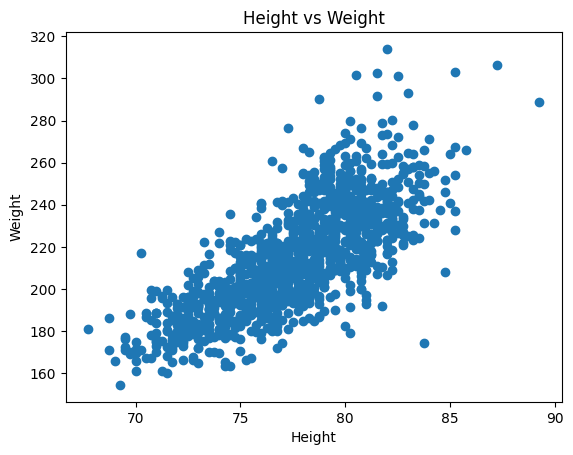

In [ ]:
plt.scatter(df['height_wo_shoes'], df['weight'])

plt.title('Height vs Weight')
plt.xlabel('Height')
plt.ylabel('Weight')

The scatter plot shows a strong positive relationship between height and weight among NBA Draft Combine players. As player height increases, weight generally increases as well. Most players cluster between 74–82 inches in height and 180–250 pounds in weight. There are also several outliers representing exceptionally tall or heavy prospects, which we will explore later.

# Answer (4)

Text(0, 0.5, 'Max Vert')

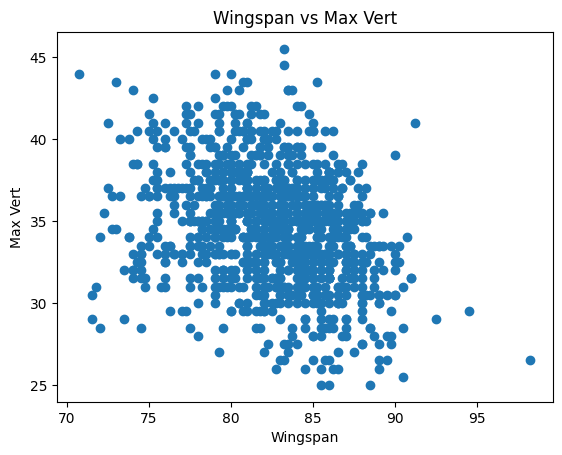

In [57]:
plt.scatter(df['wingspan'], df['max_vertical_leap'])

plt.title('Wingspan vs Max Vert')
plt.xlabel('Wingspan')
plt.ylabel('Max Vert')

The scatter plot shows a weak or slightly negative relationship between wingspan and maximum vertical leap. Players with longer wingspans do not necessarily achieve higher vertical jumps. Most players cluster between 78–88 inches in wingspan and 30–38 inches in max vertical leap, suggesting that wingspan alone is not a strong predictor of jumping ability.

# Answer (5)

In [61]:
elite_guards = df[
    (df['position'].isin(['PG', 'SG', 'PG-SG', 'SG-PG'])) &
    (df['max_vertical_leap'] > 34.5) &
    (df['standing_reach'] > 104) &
    (df['wingspan'] > 82.75)
]

elite_guards[['player_name',
               'position',
               'max_vertical_leap',
               'standing_reach',
               'wingspan']]

,player_name,position,max_vertical_leap,standing_reach,wingspan
462,Xavier Henry,SG,36.5,105.0,83.25
1114,Jalen Williams,SG,39.0,105.5,86.25
1158,Maxwell Lewis,SG,36.5,104.5,84.00


Very few guards met the elite athletic thresholds (over 50th percentile in all three) for vertical leap, standing reach, and wingspan simultaneously. Players such as Jalen Williams demonstrated exceptional physical profiles, combining elite explosiveness with uncommon length for a guard.

# Answer (6)

In [66]:
heaviest_idx = df.groupby('season')['weight'].idxmax()

heaviest_players = df.loc[
    heaviest_idx,
    ['season', 'player_name', 'weight']
]

heaviest_players

,season,player_name,weight
23,2001,DeSagana Diop,314.0
150,2004,Tom Timmerrmans,272.0
171,2005,Marcus Campbell,280.4
258,2007,Aaron Gray,271.0
343,2008,Kentrell Gransberry,290.0
396,2009,DeJuan Blair,276.6
475,2010,Dexter Pittman,302.6
540,2011,Jeremy Tyler,262.4
555,2012,Andre Drummond,278.6
631,2013,Colton Iverson,262.8


In [67]:
tallest_idx = df.groupby('season')['height_wo_shoes'].idxmax()

tallest_players = df.loc[
    tallest_idx,
    ['season', 'player_name', 'height_wo_shoes']
]

tallest_players

,season,player_name,height_wo_shoes
15,2001,Eric Chenowith,85.00
136,2004,Peter Ramos,85.75
164,2005,Martynas Andriuskevicius,85.25
258,2007,Aaron Gray,84.00
341,2008,Vladimir Golubovic,83.25
435,2009,Hasheem Thabeet,85.25
439,2010,Solomon Alabi,83.50
541,2011,Nikola Vucevic,82.25
576,2012,Meyers Leonard,83.75
625,2013,Rudy Gobert,84.50
